In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sreeshsree/creditcard-fraud/creditcard.csv


**Credit Card Fraud Detection Project**


In [4]:
# -------- Import Libraries --------

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Data preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# Handling imbalanced dataset
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

# Model evaluation
import sklearn.metrics as metrics
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    precision_recall_curve,
    f1_score,
    fbeta_score,
    accuracy_score,
    classification_report
)

# -------- Visualization Settings --------

plt.style.use('ggplot')

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size':12,
    'axes.titlesize':18,
    'axes.labelsize':12,
    'xtick.labelsize':10,
    'ytick.labelsize':10,
    'legend.fontsize':10
})


In [5]:
df=pd.read_csv('/kaggle/input/datasets/sreeshsree/creditcard-fraud/creditcard.csv')
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Exploratory Data Analysis**

In [6]:
# Printing random sample of 10 rows to check data loading

df.sample(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
84873,60501.0,1.111817,-0.732964,1.364529,0.694095,-1.409304,0.546657,-1.172610,0.395843,-0.377720,...,-0.327644,-0.372701,0.111409,0.168088,0.130517,-0.391895,0.099838,0.034140,34.00,0
192184,129576.0,-0.678885,-0.130601,1.391568,-2.744854,-0.053355,-0.181056,0.378643,0.088239,-0.540807,...,-0.722620,-1.413477,-0.341357,-0.406487,0.584101,0.494058,-0.029166,0.020686,6.99,0
145694,87136.0,1.877343,0.145775,-0.230411,3.423453,0.243275,1.231597,-0.726967,0.455966,-0.467728,...,0.188163,0.432838,0.174856,-0.045665,-0.274135,-0.006382,-0.008279,-0.043496,7.57,0
17248,28566.0,1.144010,-0.640487,0.194911,-0.173791,-1.256695,-1.352945,-0.317943,-0.250031,-0.649008,...,0.017217,-0.180679,-0.037588,0.857206,0.360811,-0.345360,0.001370,0.061829,119.24,0
106515,69994.0,-1.501403,1.541693,-0.047891,2.790681,-2.097118,1.451502,1.526424,0.849354,-1.854570,...,0.194406,0.566867,0.366161,0.019593,-0.400459,0.230370,0.449653,0.051977,433.54,0
19754,30528.0,0.785154,-1.423956,0.833834,-0.791746,-1.676843,-0.226093,-0.620551,0.136283,2.496025,...,0.158064,0.497746,-0.254065,0.492170,0.428889,0.161547,0.033351,0.052361,206.00,0
125084,77529.0,-1.234800,1.422027,1.927075,0.759214,-0.447203,-0.300919,0.143565,0.428146,-1.058233,...,0.003282,-0.213178,-0.054134,0.511912,0.106555,-0.542127,-0.278418,0.000491,7.68,0
208790,137274.0,-0.131284,1.016980,-0.339672,-0.915881,1.398274,-0.211728,1.148400,-0.168948,-0.084920,...,-0.267389,-0.518270,0.066574,0.110999,-1.059076,-0.013940,0.117229,0.075550,1.79,0
284099,172150.0,2.080279,0.216415,-1.708231,0.396953,0.513083,-0.831852,0.237977,-0.278397,0.376830,...,-0.359242,-0.888860,0.324037,0.503799,-0.223794,0.172342,-0.057459,-0.029361,1.29,0
272931,165338.0,-3.791064,3.788848,-2.377045,-1.674837,0.266991,-0.517695,0.769470,0.260815,3.176027,...,-0.941712,-1.155093,0.171348,-0.000920,0.345749,0.087613,0.948338,0.127994,11.64,0


We can only work with three non-transformed variables which are Time, Amount, and Class (where Class takes values of 1 for fraud and 0 for not fraud).

In [7]:
# Printing data overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:

# Printing numerical summary for Time and Amount columns

df.loc[:,['Time','Amount']].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


From the plot, we can observe that the Time feature has a bimodal distribution with two peaks, indicating that there are two periods during the day when credit card transactions are more frequent. The first peak occurs at around 50,000 seconds (approximately 14 hours), while the second peak occurs at around 120,000 seconds (approximately 33 hours). This suggests that there may be a pattern in the timing of credit card transactions that could be useful for fraud detection.

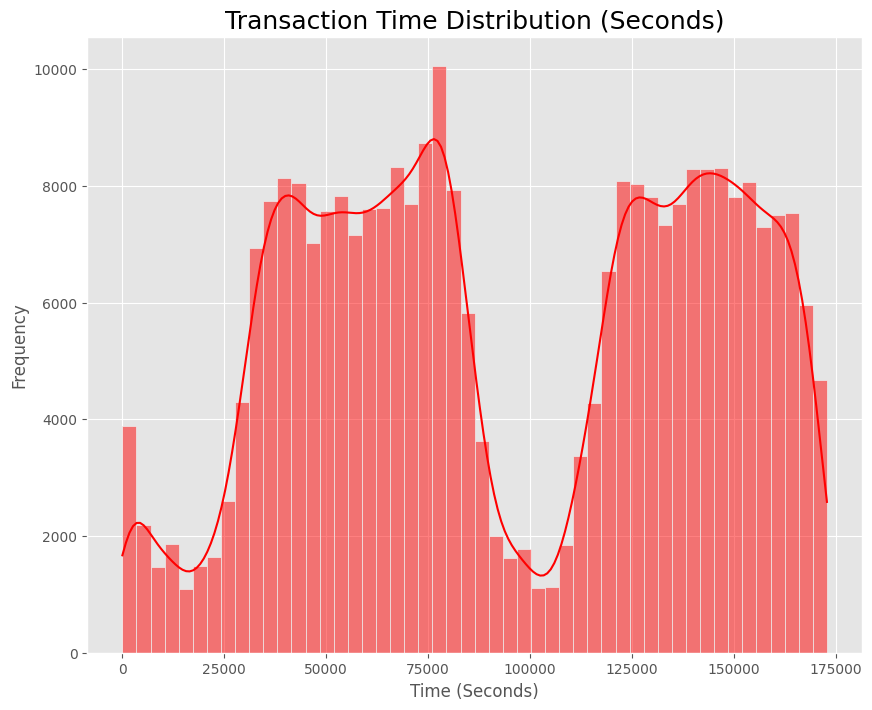

In [9]:
# Plot distribution of Time feature

plt.figure(figsize=(10,8))

sns.histplot(df['Time'],bins=50,kde=True,color='red')
plt.title('Transaction Time Distribution (Seconds)')
plt.xlabel('Time (Seconds)')
plt.ylabel('Frequency')

#save plot
plt.savefig('time_distribution.png',dpi=300,bbox_inches='tight')

plt.show()




From the plot, we can observe that the distribution of the Amount feature is highly skewed to the right, with a long tail to the right. This indicates that the majority of the transactions have low amounts, while a few transactions have extremely high amounts. As a result, this suggests that the dataset contains some outliers in terms of transaction amounts. Therefore, when building a model for fraud detection, it may be necessary to handle outliers in the Amount feature, for instance, by using a log transformation or robust statistical methods.

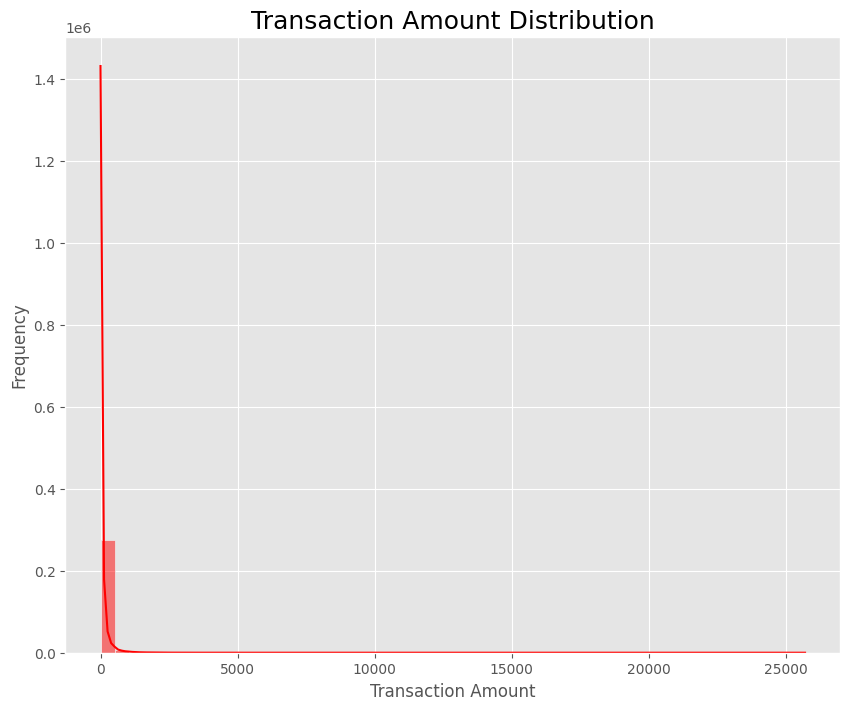

In [10]:

# Plot distribution of Amount feature

plt.figure(figsize=(10,8))

sns.histplot(df['Amount'],bins=50,kde=True,color='red')

plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

plt.savefig('amount_distribution.png',dpi=300,bbox_inches='tight')
plt.show()

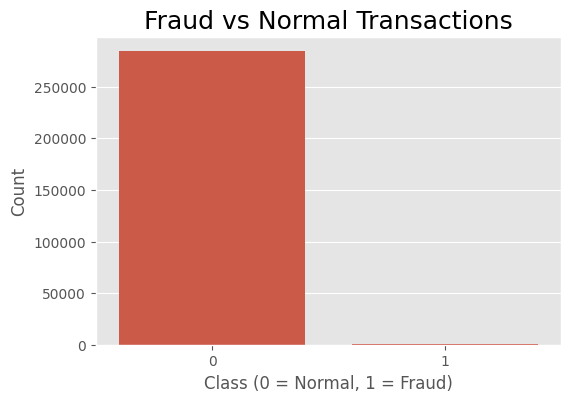

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df)

plt.title('Fraud vs Normal Transactions')
plt.xlabel('Class (0 = Normal, 1 = Fraud)')
plt.ylabel('Count')

plt.show()

In [12]:
# Counting number of fraud vs non-fraud transactions and displaying them with their ratio

fraud=df['Class'].value_counts()[1]
nonfraud=df['Class'].value_counts()[0]
print(f'Fraudulent:{fraud},Non-Fraudulent:{nonfraud}')

fraud_ratio = (fraud / nonfraud) * 100

print(f"Fraud to Non-Fraud Ratio : {fraud}/{nonfraud} ({fraud_ratio:.4f}%)")

Fraudulent:492,Non-Fraudulent:284315
Fraud to Non-Fraud Ratio : 492/284315 (0.1730%)


From the plot, we can observe that the dataset is highly imbalanced, with a vast majority of transactions being non-fraudulent (class 0) and a relatively small number of transactions being fraudulent (class 1). This indicates that the dataset has a class imbalance problem, which may affect the performance of a model trained on this dataset. It may be necessary to use techniques such as oversampling, undersampling, or class weighting to handle the class imbalance problem when building a model for fraud detection.

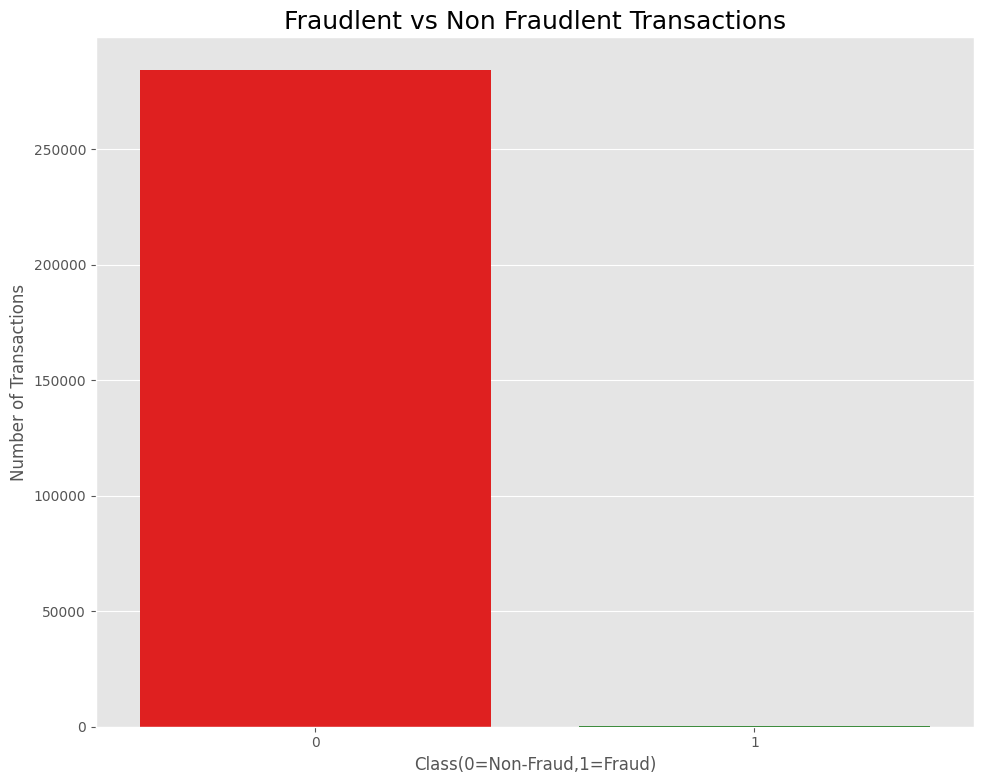

In [13]:
plt.figure(figsize=(10,8))
sns.countplot(x='Class',data=df,palette=['red','green'])

plt.title('Fraudlent vs Non Fraudlent Transactions')
plt.xlabel('Class(0=Non-Fraud,1=Fraud)')
plt.ylabel('Number of Transactions')
plt.tight_layout()

plt.savefig('fraud_vs_non_fraud_transactions.png',dpi=300)

plt.show()

**Data Processing**

 From the heatmap, it can be observed that there are no strong positive or negative correlations between any pairs of variables in the dataset. The strongest correlations are found:

* Time and V3, with a correlation coefficient of -0.42
* Amount and V2, with a correlation coefficient of 0.53
* Amount and V4, with a correlation coefficient of 0.4. 


Although these correlations are relatively high, the risk of multicollinearity is not expected to be significant. Overall, the heatmap suggests that there are no highly correlated variables that need to be removed before building a machine learning model.

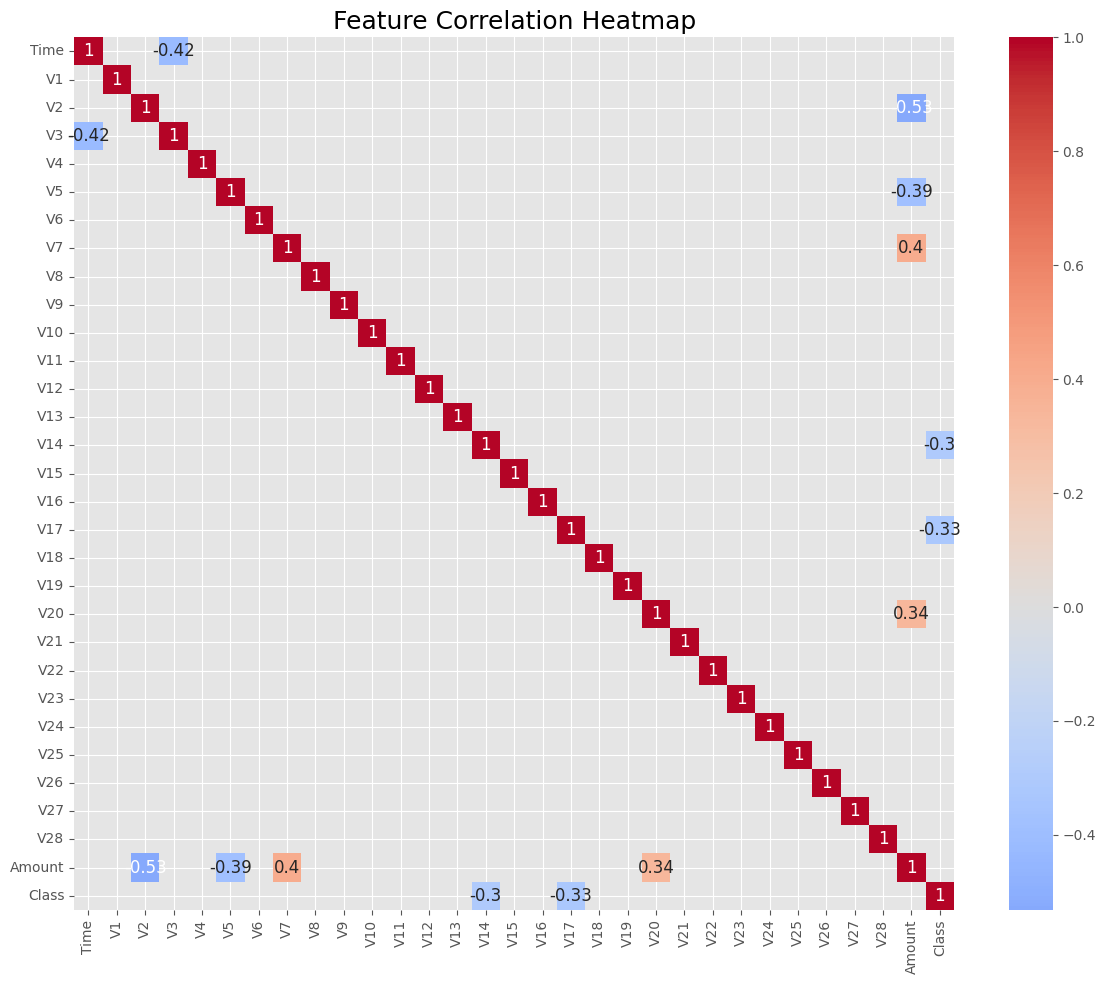

In [14]:
# Correlation Heatmap

plt.figure(figsize=(12,10))

corr=df.corr()
mask=np.abs(corr)<0.3

sns.heatmap(corr,mask=mask,cmap="coolwarm",center=0,annot=True)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()

plt.savefig("correlation_heatmap.png",dpi=300)
plt.show()

**Modeling**

1.The "Credit Card Fraud Detection" dataset has credit card transactions labeled as fraudulent or not. The dataset is imbalanced, so it needs a model that can accurately detect fraudulent transactions without wrongly flagging non-fraudulent transactions. 

2.To help with classification problems, **StandardScaler** standardizes data by giving it a mean of 0 and a standard deviation of 1, which results in a normal distribution. This technique works well when dealing with a wide range of amounts and time. To scale the data, the training set is used to initialize the fit, and the train, validation, and test sets are then scaled before running them into the models. 

3.The dataset was divided into 60% for training, 20% for validation, and 20% for testing. To balance the imbalanced dataset, **Random Undersampling** was used to match the number of fraudulent transactions. Logistic Regression and Random Forest models were used, and good results were produced. 

4.The commonly used models for the "Credit Card Fraud Detection" dataset are Logistic Regression, Naive Bayes, Random Forest, and Dummy Classifier. 

* **Logistic Regression** is widely used for fraud detection because of its interpretability and ability to handle large datasets. 
* **Naive Bayes** is commonly used for fraud detection because it can handle datasets with a large number of features and can provide fast predictions. 
* **Random Forest** is commonly used for fraud detection because it can handle complex datasets and is less prone to overfitting. 
* **The Dummy Classifier** is a simple algorithm used as a benchmark to compare the performance of other models.

In [15]:
X=df.drop(['Class'],axis=1)

y=df['Class']

In [16]:
X

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00


In [17]:
from sklearn.model_selection import train_test_split

# First split → Train + Test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

# Second split → Train + Validation
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.25,stratify=y_train,random_state=42)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


# Initialize the StandardScaler object and fit it to the training data
scaler = StandardScaler()
scaler.fit(X_train)

# Scale the training, validation, and test sets using the scaler
X_train_std = scaler.transform(X_train)
X_val_std=scaler.transform(X_val)
X_test_std = scaler.transform(X_test)



Train: (170883, 30)
Validation: (56962, 30)
Test: (56962, 30)


In [18]:
# Undersampling will be utilized to address the issue of imbalanced classes.
# Instantiate UnderSampling

rus=RandomUnderSampler(random_state=42)

# Undersample the training set

X_train_under,y_train_under = rus.fit_resample(X_train_std,y_train)

# Undersample the validation set
X_val_under, y_val_under = rus.fit_resample(X_val_std,y_val)

**Logistic Regression**

In [20]:

# Hyperparameter grid
penalty = ['l2']
C = np.logspace(0, 4, 10)

param_grid = {'C': C,'penalty': penalty}

# Logistic Regression model
logistic = LogisticRegression(solver='lbfgs',max_iter=10000)

# Grid Search with 5-fold cross validation
logistic_grid = GridSearchCV(estimator=logistic,param_grid=param_grid,cv=5,scoring='roc_auc',verbose=10,n_jobs=-1)

# Train model
logistic_grid.fit(X_train_under, y_train_under)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=10000), n_jobs=-1,
             param_grid={'C': array([1.00000000e+00, 2.78255940e+00, 7.74263683e+00, 2.15443469e+01,
       5.99484250e+01, 1.66810054e+02, 4.64158883e+02, 1.29154967e+03,
       3.59381366e+03, 1.00000000e+04]),
                         'penalty': ['l2']},
             scoring='roc_auc', verbose=10)

In [21]:
logistic_grid.best_params_


{'C': np.float64(59.94842503189409), 'penalty': 'l2'}

In [22]:
best_model = logistic_grid.best_estimator_

# Best score
print(logistic_grid.best_score_)

0.983165756966389


**Naive Bayes**

In [23]:
# Naive Bayes
# Fit a Naive Bayes Model
gnb = GaussianNB()
gnb_best = gnb.fit(X_train_under, y_train_under)

**Random Forest**

In [25]:
# Random Forest
# Run CV with 5 folds (Random Forest)
# Create the parameter grid based on the results of random search 
param_grid = {
    'max_depth': [5, 10, 15],
    'max_features': ['sqrt'],
    'min_samples_leaf': [10, 20],
    'min_samples_split': [2, 5],
    'n_estimators': [500, 700]
}

rf = RandomForestClassifier()
rf_grid = GridSearchCV(rf, param_grid, cv=5, scoring='roc_auc', verbose=1, n_jobs=-1)
rf_grid.fit(X_train_under,y_train_under)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15], 'max_features': ['sqrt'],
                         'min_samples_leaf': [10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [500, 700]},
             scoring='roc_auc', verbose=1)

**Support Vector Machine (SVM)**

In [26]:
# Support Vector Machine (SVM)
 # Run CV with 5 folds (SVM)
C = [1]
gammas = [0.001, 0.1]
param_grid = dict(C=C, gamma=gammas)

svm1 = svm.SVC(kernel='rbf', probability=True)
svm_grid = GridSearchCV(svm1, param_grid, cv=5, scoring='roc_auc', verbose=10, n_jobs=-1)
svm_grid.fit(X_train_under, y_train_under)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


GridSearchCV(cv=5, estimator=SVC(probability=True), n_jobs=-1,
             param_grid={'C': [1], 'gamma': [0.001, 0.1]}, scoring='roc_auc',
             verbose=10)

**Model Evaluation**

**Find ROC scores for all models**

In [30]:
def plot_roc_curves(X, y, models, model_names, figsize=(20,18)):

    fig, ax = plt.subplots(figsize=figsize)
    # Loop over models and plot ROC curve
    for i, model in enumerate(models):
        y_pred = list(model.predict_proba(X)[:, 1])
        fpr, tpr, threshold = metrics.roc_curve(y, y_pred)
        roc_auc = metrics.auc(fpr, tpr)
        plt.plot(fpr, tpr, label=(model_names[i] + ' AUC = %0.4f' % roc_auc), linewidth=2.0)

    ax.grid(False)
    ax.tick_params(length=6, width=2, labelsize=30, grid_color='r', grid_alpha=0.5)
    leg = plt.legend(loc='lower right', prop={'size': 25})
    leg.get_frame().set_edgecolor('b')
    plt.title('Receiver Operating Characteristic (ROC)', fontsize=40)
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlim([-.02, 1.02])
    plt.ylim([-.02, 1.02])
    plt.ylabel('True Positive Rate', fontsize=30)
    plt.xlabel('False Positive Rate', fontsize=30)
    plt.show()

In [32]:
# Define the list of models to compare
models = [logistic_grid.best_estimator_, gnb_best, rf_grid.best_estimator_]
model_names = ['Logit', 'Naive Bayes', 'Random Forest']

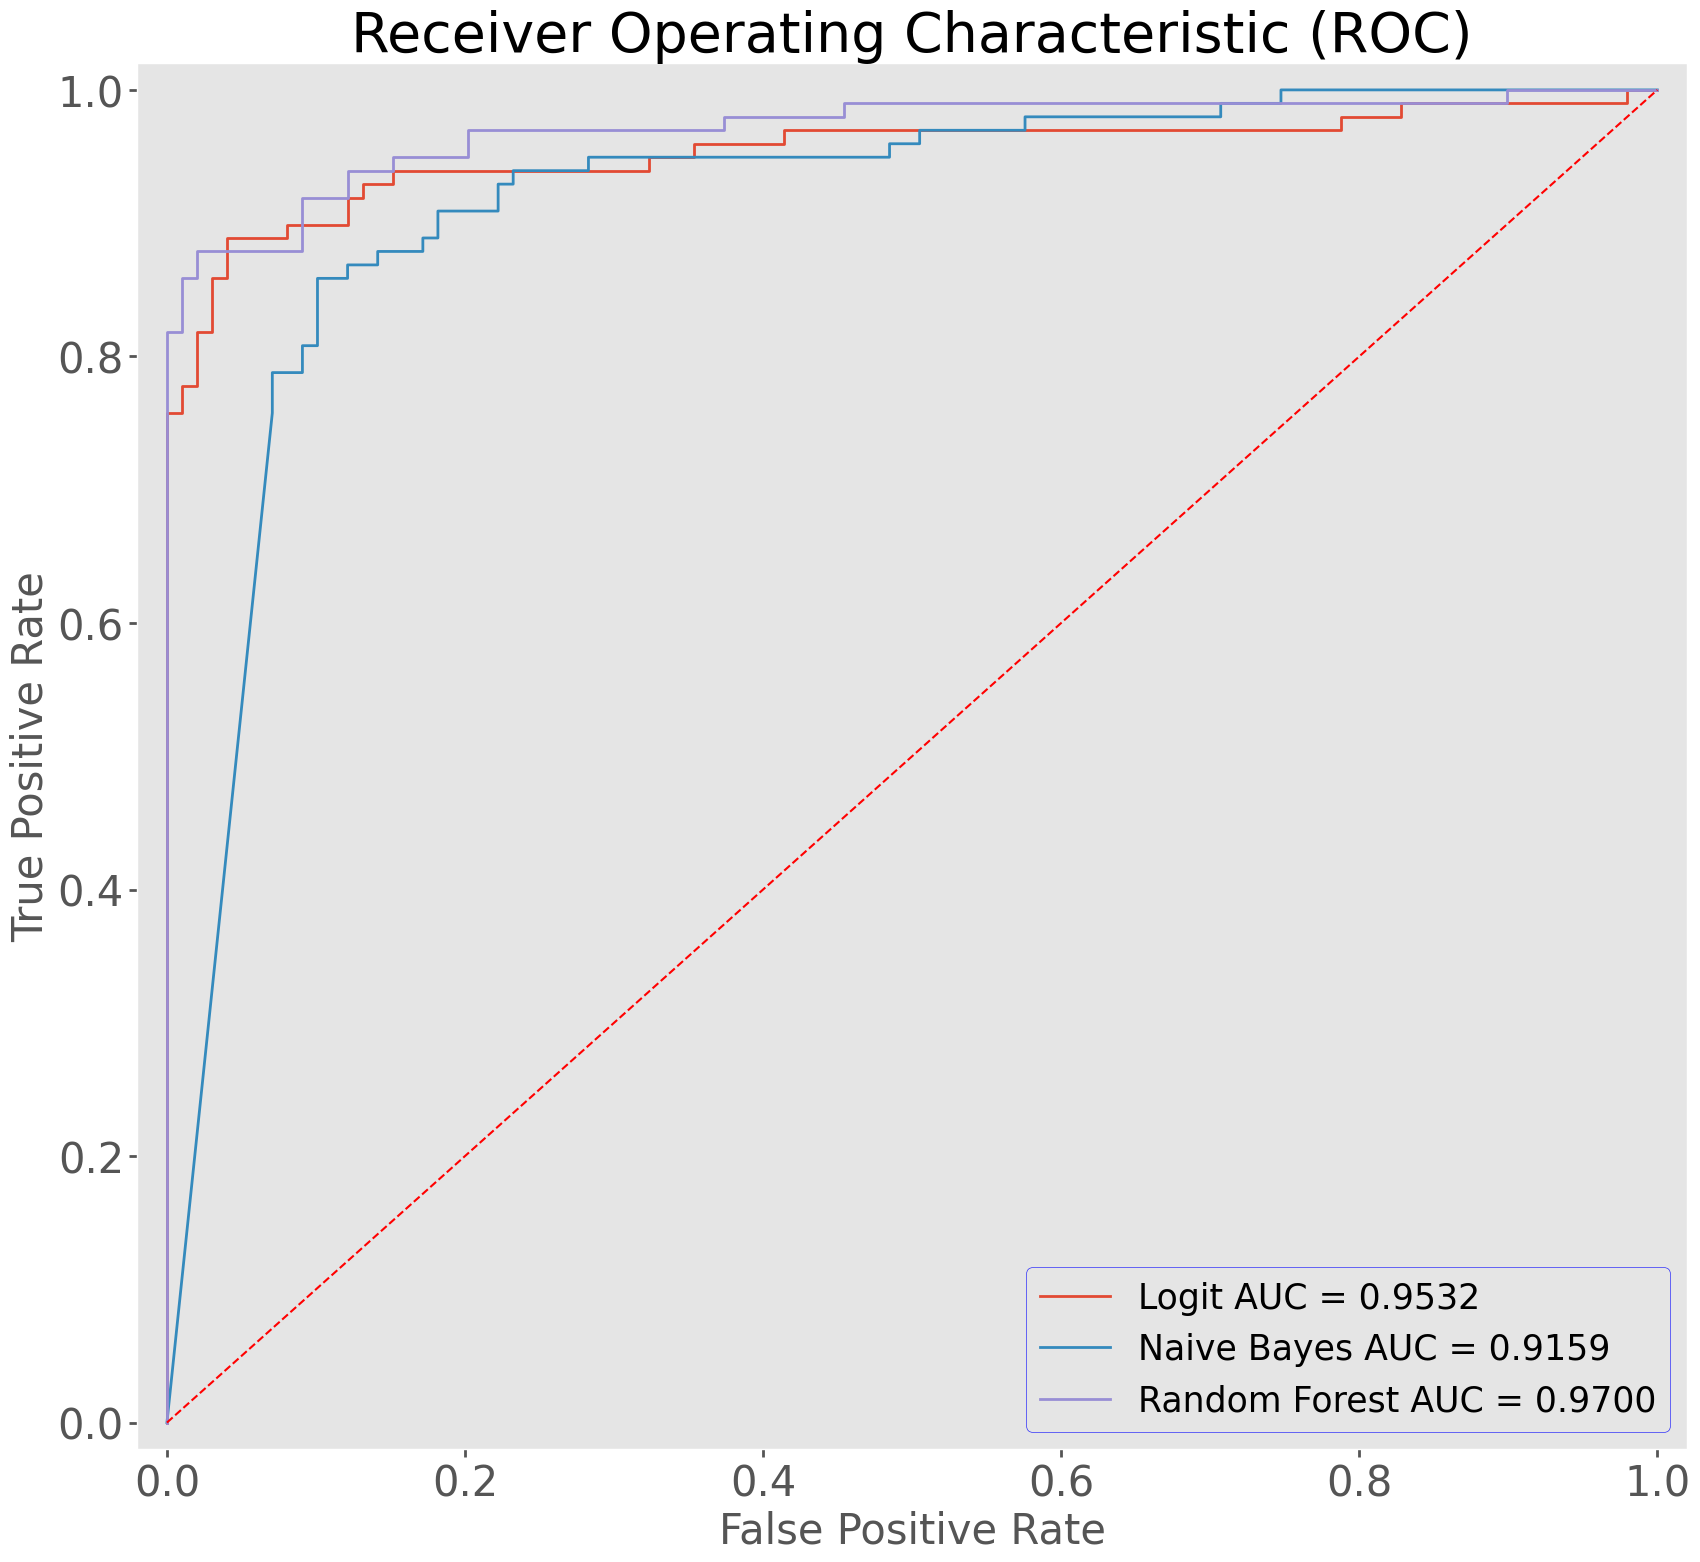

<Figure size 640x480 with 0 Axes>

In [33]:
# Plot ROC curves for in-sample data
plot_roc_curves(X_val_under, y_val_under, models, model_names)

# Save the plot as PNG file
plt.savefig('roc_insample.png');

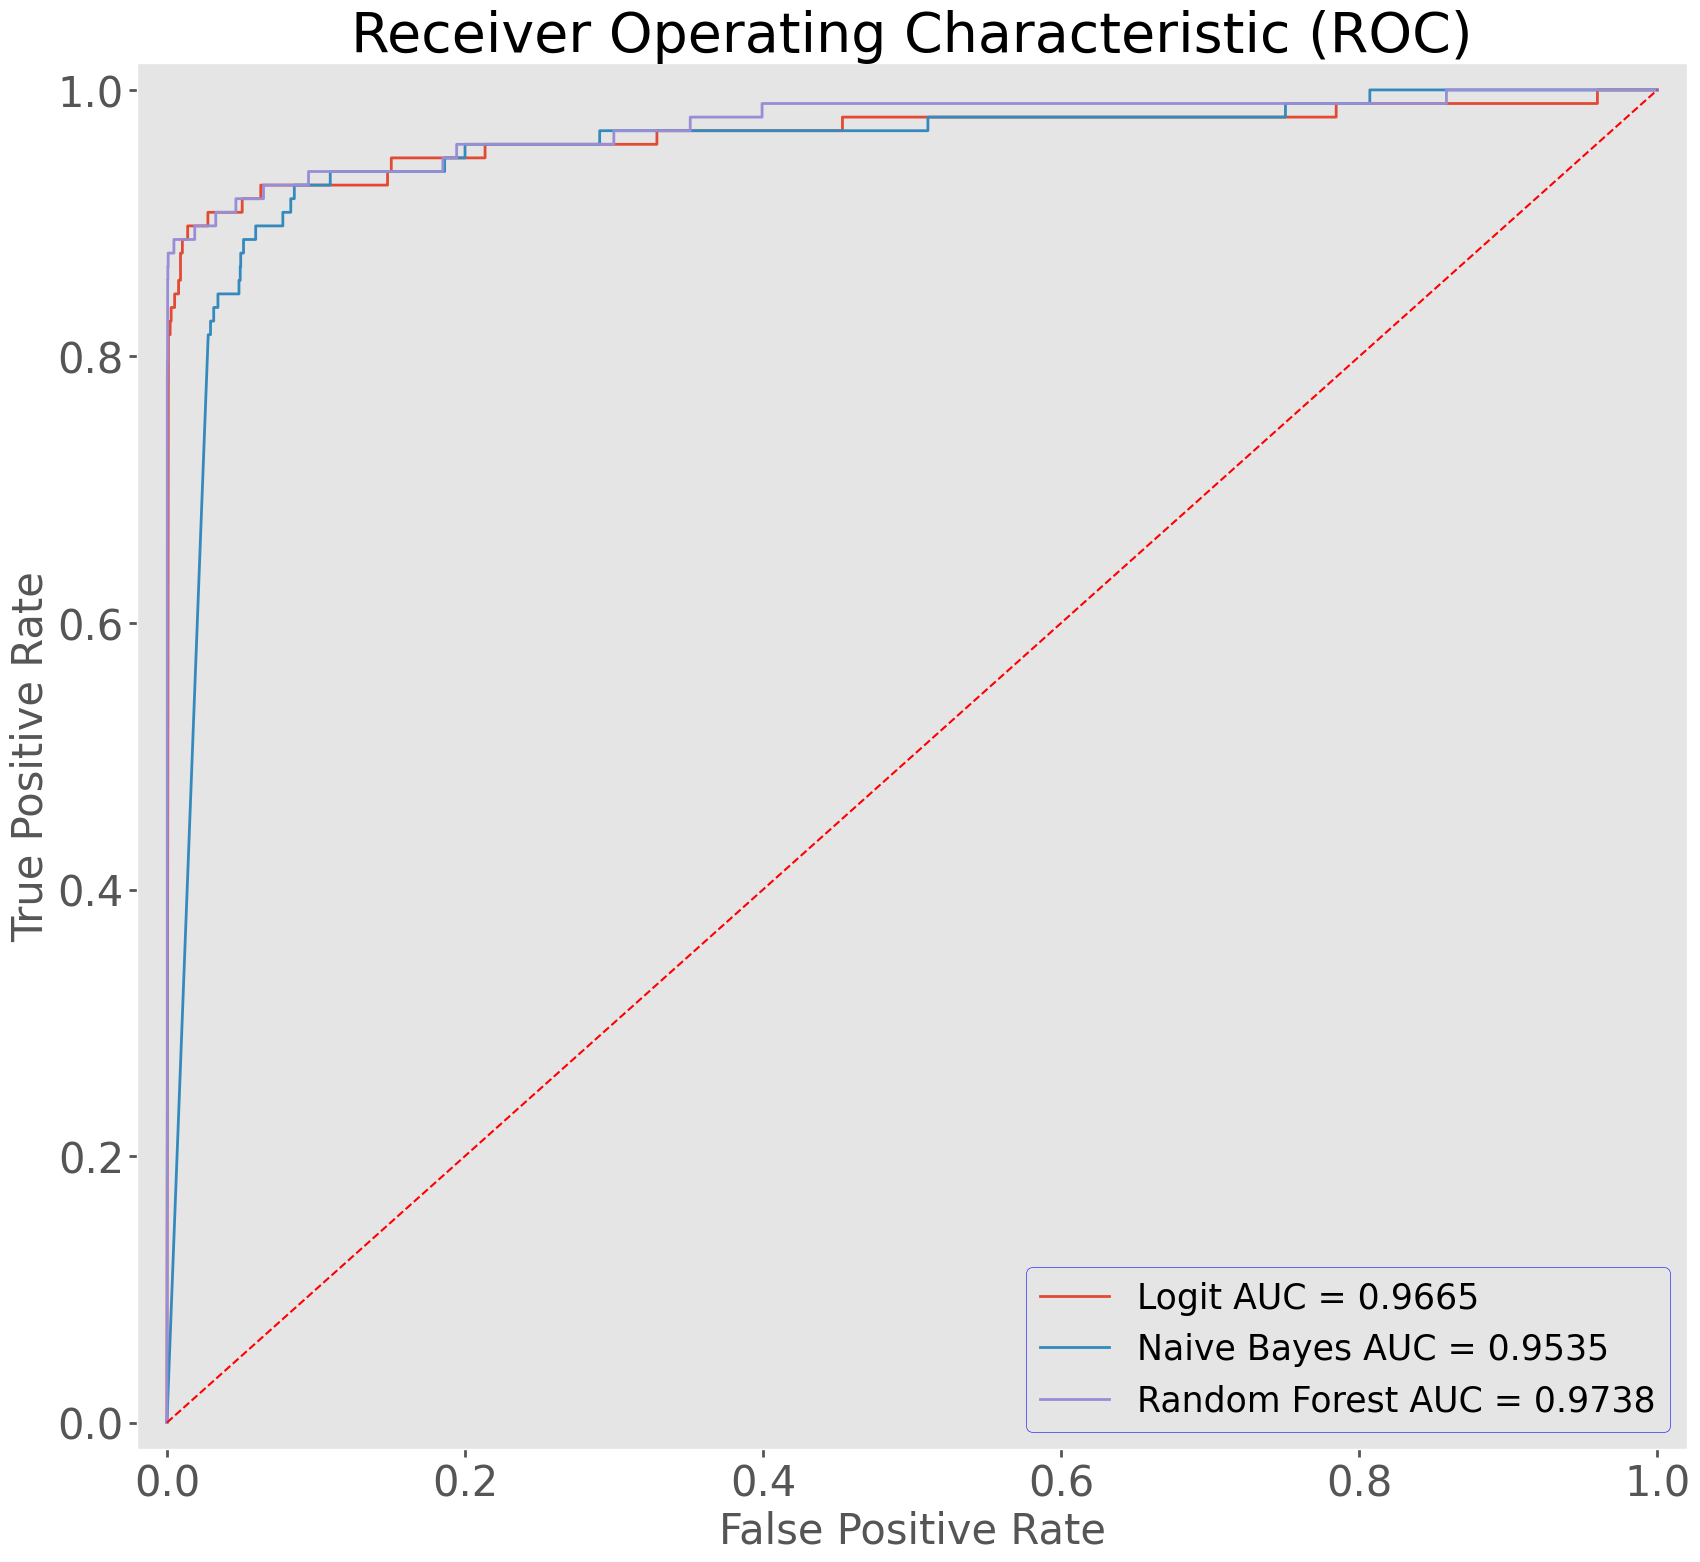

<Figure size 640x480 with 0 Axes>

In [34]:
# Plot ROC curves for out-of-sample data
plot_roc_curves(X_test_std, y_test, models, model_names)

# Save the plot as PNG file
plt.savefig('roc_outsample.png');

* Recall (True Positive Rate): This metric measures the percentage of all fraudulent transactions that the model correctly identifies as fraudulent.
* Precision: This metric indicates the percentage of items that the model labels as fraud that are actually fraudulent.
* False Positive Rate: This metric measures the percentage of non-fraudulent transactions that the model incorrectly labels as fraudulent.
* Accuracy: This metric reflects how often the model is correct in its predictions overall. However, it can be misleading in the case of imbalanced data or fraud detection.
* F1 score: This metric is a combination of precision and recall, taking both false positives and false negatives into    account. It's a weighted average of precision and recall and is usually more useful than accuracy, especially when       dealing with uneven classes.

**Determine the optimal threshold for each model.**

✅ The function find_best_threshold() can be used to determine the optimal threshold for a given model. The optimal threshold is the value that maximizes the F1 score, a measure that combines precision and recall, for a binary classification problem.

✅ The function takes two arguments: model is the trained model, and num_steps is the number of steps in the threshold range to iterate over.

✅ The function first initializes variables for the highest F1 score, the best threshold, and the best accuracy, recall, and precision scores. It then iterates over a range of thresholds from 0 to 1, with num_steps steps. For each threshold, it predicts the target variable using the given threshold and calculates the F1 score, accuracy, recall, and precision scores. If the F1 score is higher than the current highest F1 score, it updates the best threshold and evaluation metrics.

✅ After iterating over all the thresholds, the function returns the best threshold and the corresponding F1 score, accuracy, recall, and precision scores.

✅ The math equation to find the F1 score is:

F1 = 2 * (precision * recall) / (precision + recall)

where

precision = TP / (TP + FP)
recall = TP / (TP + FN)
TP: True Positive (model predicts positive and it is positive)
FP: False Positive (model predicts positive but it is negative)
FN: False Negative (model predicts negative but it is positive)

In [36]:
# Define a function to find the best threshold for a given model
def find_best_threshold(model, num_steps):
    highest_f1 = 0
    best_threshold = 0
    best_acc = 0
    best_rec = 0
    best_pre = 0
    # Iterate over a range of thresholds
    for threshold in np.linspace(0, 1, num_steps):
        # Predict the target variable using the given threshold
        y_predict = (model.predict_proba(X_val_under)[:, 1] >= threshold)
        # Calculate various evaluation metrics
        f1 = f1_score(y_val_under, y_predict)
        acc = accuracy_score(y_val_under, y_predict)
        rec = recall_score(y_val_under, y_predict)
        pre = precision_score(y_val_under, y_predict)
        # Update the best threshold and metrics if F1 score improves
        if f1 > highest_f1:
            best_threshold, highest_f1, best_acc, best_rec, best_pre = \
                threshold, f1, acc, rec, pre
    # Return the best threshold and evaluation metrics
    return best_threshold, highest_f1, best_acc, best_rec, best_pre

In [37]:
# Define a list of models and their names
models = [logistic_grid, gnb_best, rf_grid]
model_names = ["Logistic Regression", "Naive-Bayes", "Random Forest"]

In [38]:
# Create an empty list to store the results
chart = list()

# Iterate over the models and find the best threshold for each one
for item, name in zip(models, model_names):
    best_thresh, high_f1, high_acc, high_rec, high_pre = find_best_threshold(item, 20)
    # Append the results to the chart list
    chart.append([name, best_thresh, high_f1, high_acc, high_rec, high_pre])

# Create a pandas dataframe from the chart list and display it
chart = pd.DataFrame(chart, columns=['Model', 'Best Threshold', 'F1 Score', 'Accuracy', 'Recall', 'Precision'])
chart.to_csv('model_evaluation_scores.csv')
chart

,Model,Best Threshold,F1 Score,Accuracy,Recall,Precision
0,Logistic Regression,0.894737,0.921466,0.924242,0.888889,0.956522
1,Naive-Bayes,0.052632,0.870466,0.873737,0.848485,0.893617
2,Random Forest,0.421053,0.925532,0.929293,0.878788,0.977528


**Confusion Matrix**

In [39]:
def make_confusion_matrix_val(model, threshold=0.5):
    """
    Create a confusion matrix plot for the given model and threshold. 
    
    Parameters:
    -----------
    model : sklearn classifier
        The classification model to evaluate.
    threshold : float, default=0.5
        Probability threshold for binary classification.
        
    Returns:
    --------
    None
    
    """
    # Predict class 1 if probability of being in class 1 is greater than threshold
    # (model.predict(X_test) does this automatically with a threshold of 0.5)
    y_predict = (model.predict_proba(X_val_under)[:, 1] >= threshold)
    
    # calculate the confusion matrix
    fraud_confusion = confusion_matrix(y_val_under, y_predict)
    
    # plot the confusion matrix as heatmap
    plt.figure(dpi=100)
    sns.set(font_scale=1)
    sns.heatmap(fraud_confusion, cmap=plt.cm.Blues, annot=True, square=True, fmt='d',
           xticklabels=['Not Fraud', 'Fraud'],
           yticklabels=['Not Fraud', 'Fraud']);
    
    # calculate TP, FP, FN, and TN values from the confusion matrix
    TP = fraud_confusion[0][0]
    FP = fraud_confusion[0][1]
    FN = fraud_confusion[1][0]
    TN = fraud_confusion[1][1]
    
    # rotate y-axis ticks
    plt.yticks(rotation = 0)
    
    # set plot title, x and y labels
    plt.title('Predicted vs. Actual',fontname = '.SF Compact Display',fontsize = 20,pad = 10);
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.


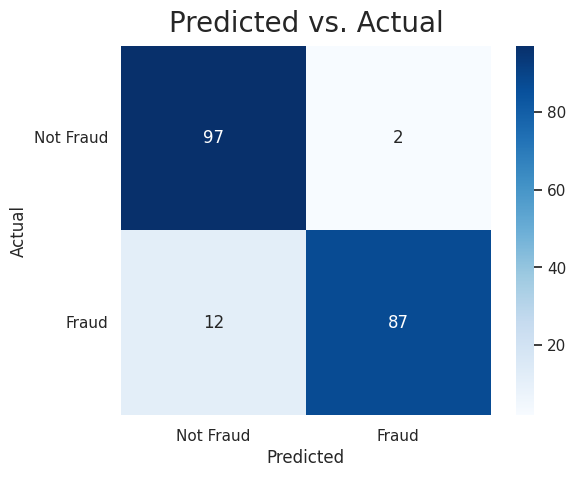

In [40]:
# Create a confusion matrix for the Random Forest model with a threshold of 0.421 on the validation data
make_confusion_matrix_val(rf_grid, threshold=0.421)

# Save the plot as PNG file
plt.savefig('confusion_matrix_val_random_forest.png');

findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.


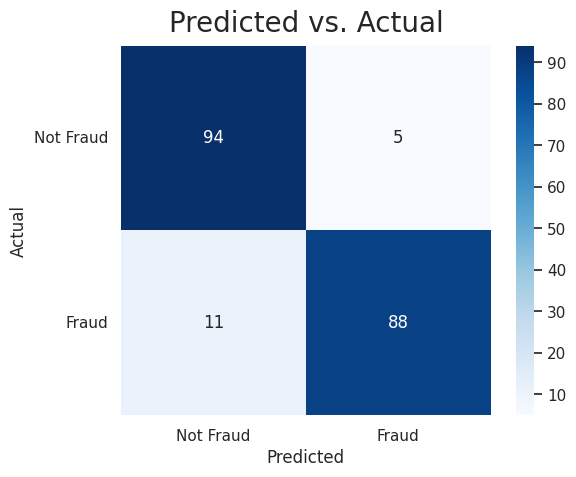

In [41]:
# Create a confusion matrix for the Logistic Regression model with a threshold of 0.842 on the validation data
make_confusion_matrix_val(logistic_grid, threshold=0.842)

# Save the plot as PNG file
plt.savefig('confusion_matrix_val_logistic_regression.png');

In [42]:
def make_confusion_matrix_test(model, threshold=0.5):
    """
    Generates a confusion matrix for a given model on the test dataset, given a threshold.

    Args:
    - model: a trained machine learning model
    - threshold: threshold for binary classification

    Returns: None
    """

    # Predict class 1 if probability of being in class 1 is greater than threshold
    y_predict = (model.predict_proba(X_test_std)[:, 1] >= threshold)

    # Generate confusion matrix
    fraud_confusion = confusion_matrix(y_test, y_predict)

    # Plot heatmap of confusion matrix
    plt.figure(dpi=100)
    sns.set(font_scale=1)
    sns.heatmap(fraud_confusion, cmap=plt.cm.Blues, annot=True, square=True, fmt='d',
                xticklabels=['Not Fraud', 'Fraud'],
                yticklabels=['Not Fraud', 'Fraud'])

    # Calculate TP, FP, FN, TN
    TP = fraud_confusion[0][0]
    FP = fraud_confusion[0][1]
    FN = fraud_confusion[1][0]
    TN = fraud_confusion[1][1]

    # Add title, labels and rotate y-tick labels
    plt.yticks(rotation=0)
    plt.title('Predicted vs. Actual', fontname='.SF Compact Display', fontsize=20, pad=10)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.


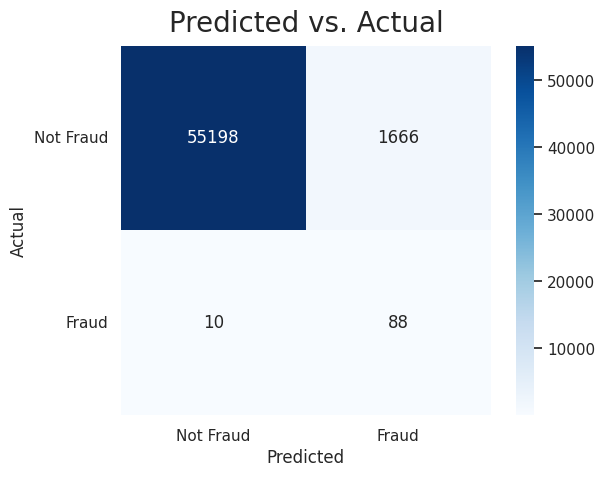

In [43]:
# Generate confusion matrix for random forest model on test dataset
make_confusion_matrix_test(rf_grid, threshold=0.421)

# Save the plot as PNG file
plt.savefig('confusion_matrix_test_random_forest.png');

findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.
findfont: Font family '.SF Compact Display' not found.


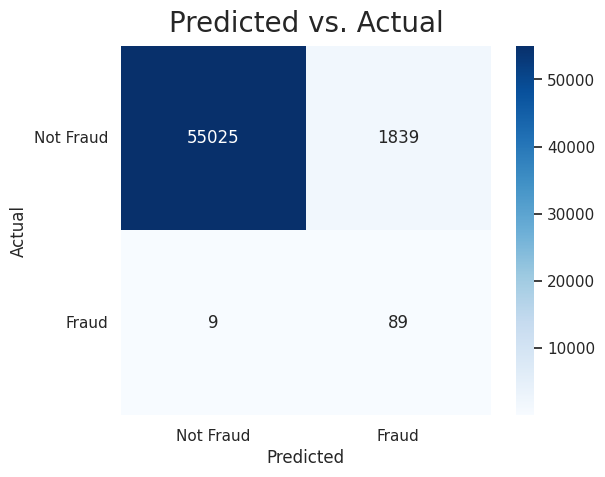

In [44]:
# Generate confusion matrix for logistic regression model on test dataset
make_confusion_matrix_test(logistic_grid, threshold=0.842)

# Save the plot as PNG file
plt.savefig('confusion_matrix_test_logistic_regression.png');